# Final evaluation results

Full run — **n=1000** questions per variant (HotpotQA), grading `2026-07-11`. This run adds the
**`fullcontext`** oracle baseline (each question is fed its own gold context, no retrieval) as the
accuracy ceiling.

Four questions:

1. **Latency** — average wall-clock time per question.
2. **Token cost (test-time only)** — average tokens per question, *ignoring* ingest.
3. **Token cost (incl. ingest)** — same, but the one-time graph-extraction ingest cost is
   folded into the variants that actually use the graph.
4. **Accuracy vs context, and break-even** — from the `top_k` sweep: pure `vector` RAG must fetch
   far more context to reach the accuracy that `vectorgraphtext` reaches cheaply — and after how
   many questions that cheaper per-query search pays back the upfront ingest cost.

Sources: `evaluations/summary_table.json` (final per-variant metrics) and
`evaluations/sweeps/20260707T032745Z/sweep_summary.csv` (top_k sweep).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

EVAL = Path("../evaluations")

# Final per-variant metrics (one row per variant)
sdf = pd.DataFrame(json.load(open(EVAL / "summary_table.json"))).T
sdf.index.name = "variant"

# top_k sweep (accuracy / tokens per top_k per variant)
swp = pd.read_csv(EVAL / "sweeps" / "20260707T032745Z" / "sweep_summary.csv")

# Ingest cost is the shared unified graph-extraction cost (identical on every row).
INGEST_TOKENS = int(sdf["ingest_tokens_total"].iloc[0])   # 6,302,709 tokens
N_EVAL        = int(sdf["n"].iloc[0])                       # 1000 questions graded
# Only variants that actually build/use the graph are charged the ingest cost.
GRAPH_VARIANTS = {"graph", "graphtext", "vectorgraphtext"}

# vectorgraph was an experimental beam-traversal variant — omit it from the writeup.
sdf = sdf.drop(index="vectorgraph", errors="ignore")

print(f"variants: {list(sdf.index)}")
print(f"ingest tokens (shared): {INGEST_TOKENS:,}   |   n eval: {N_EVAL}")
sdf[["accuracy_em", "accuracy_judge", "query_latency_ms_mean", "query_tokens_total_mean"]]

variants: ['bm25', 'fullcontext', 'graph', 'graphtext', 'vector', 'vectorgraphtext']
ingest tokens (shared): 6,302,709   |   n eval: 1000


,accuracy_em,accuracy_judge,query_latency_ms_mean,query_tokens_total_mean
variant,,,,
bm25,0.331,0.4055,409.10,397.01
fullcontext,0.475,0.5905,583.39,1350.15
graph,0.238,0.2795,661.39,121.09
graphtext,0.393,0.4795,660.05,434.22
vector,0.369,0.4525,425.17,424.44
vectorgraphtext,0.417,0.5165,600.55,424.20


In [2]:
# --- Design system: fixed categorical colors per variant (CVD-safe, validated) ---
# Extends the palette from topk_context_analysis.ipynb with vectorgraph + fullcontext.
# Color follows the entity (variant), never its rank.
VARIANT_COLOR = {
    "vector":          "#2a78d6",  # blue
    "vectorgraphtext": "#1baf7a",  # aqua-green
    "bm25":            "#eda100",  # yellow
    "graphtext":       "#4a3aa7",  # violet
    "graph":           "#e34948",  # red
    "vectorgraph":     "#c74fb0",  # magenta
    "fullcontext":     "#00a0b0",  # teal  (oracle ceiling)
}
VARIANT_LABEL = {
    "vector": "Vector", "vectorgraphtext": "VectorGraphText", "bm25": "BM25",
    "graphtext": "GraphText", "graph": "Graph", "vectorgraph": "VectorGraph",
    "fullcontext": "FullContext",
}
# Fixed display order, shared by every chart so variants line up 1:1 across figures.
VARIANT_ORDER = ["fullcontext", "bm25", "vector", "graph", "graphtext", "vectorgraphtext"]

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#bababa"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

# All final per-variant metrics come from the top_k=3 grading run.
TOPK = 3

def xlabel_topk(base, k=TOPK):
    """Append the operating point to an axis label instead of a floating stamp."""
    return f"{base}   (top_k = {k})"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 120, "savefig.dpi": 120,
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 10,
})

def hbar_ordered(values: pd.Series, title, xlabel, fmt, extra=None):
    """Horizontal bars in the fixed VARIANT_ORDER (first listed on top), one color per
    variant, direct value labels, top_k noted on the x-axis.
    `extra` optionally stacks a second (ingest) segment: dict variant->value."""
    # bottom-to-top plotting order, so VARIANT_ORDER[0] ends up at the top
    order = [v for v in VARIANT_ORDER if v in values.index][::-1]
    s = values.reindex(order)
    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    y = np.arange(len(s))
    colors = [VARIANT_COLOR[v] for v in s.index]
    ax.barh(y, s.values, color=colors, height=0.68, zorder=3)
    if extra is not None:
        add = np.array([extra.get(v, 0.0) for v in s.index])
        ax.barh(y, add, left=s.values, color=colors, alpha=0.32, height=0.68,
                zorder=3, hatch="////", edgecolor=SURFACE, linewidth=1.4)
        for yi, base, a in zip(y, s.values, add):
            if a > 0:
                ax.text(base + a + s.values.max() * 0.012, yi, fmt(base + a),
                        va="center", ha="left", fontsize=9.5, color=INK)
            else:
                ax.text(base + s.values.max() * 0.012, yi, fmt(base),
                        va="center", ha="left", fontsize=9.5, color=INK)
    else:
        for yi, v in zip(y, s.values):
            ax.text(v + s.values.max() * 0.012, yi, fmt(v),
                    va="center", ha="left", fontsize=9.5, color=INK)
    ax.set_yticks(y)
    ax.set_yticklabels([VARIANT_LABEL[v] for v in s.index])
    ax.set_xlabel(xlabel_topk(xlabel))
    ax.set_title(title)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.margins(x=0.14)
    return fig, ax

## Accuracy by variant — the headline

Before the cost/latency tradeoffs, the bottom line: **how accurate is each variant?** Both metrics
are shown per variant — **LLM-judge** (semantic correctness) and **exact match (EM)** — in the
fixed variant order used across every chart. `fullcontext` is the oracle ceiling; among the
retrieval variants `vectorgraphtext` leads. All numbers are from the top_k=3 grading run.

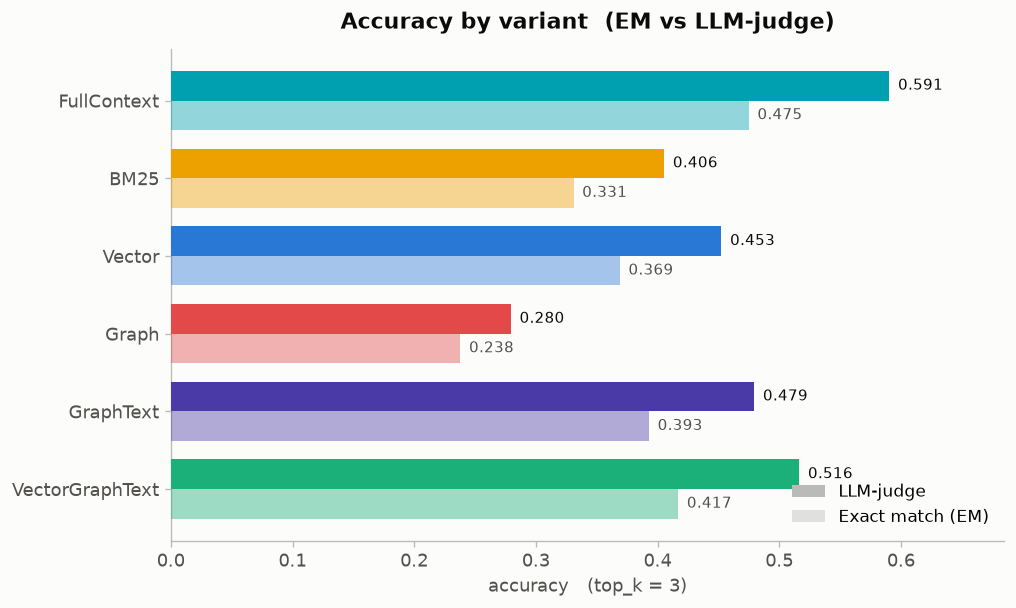

In [3]:
from matplotlib.patches import Patch

# Grouped horizontal bars: LLM-judge (solid) vs exact-match (translucent), one color per variant.
# Fixed VARIANT_ORDER (first listed on top) so this lines up with every other chart.
order = [v for v in VARIANT_ORDER if v in sdf.index][::-1]
adf = sdf.loc[order, ["accuracy_judge", "accuracy_em"]].astype(float)
variants = list(adf.index)
y = np.arange(len(variants))
h = 0.38
colors = [VARIANT_COLOR[v] for v in variants]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.barh(y + h / 2, adf["accuracy_judge"].values, height=h, color=colors, zorder=3)
ax.barh(y - h / 2, adf["accuracy_em"].values, height=h, color=colors, alpha=0.42, zorder=3)

xmax = adf["accuracy_judge"].max()
for yi, jv, ev in zip(y, adf["accuracy_judge"].values, adf["accuracy_em"].values):
    ax.text(jv + xmax * 0.012, yi + h / 2, f"{jv:.3f}", va="center", ha="left",
            fontsize=9, color=INK)
    ax.text(ev + xmax * 0.012, yi - h / 2, f"{ev:.3f}", va="center", ha="left",
            fontsize=9, color=INK2)

ax.set_yticks(y)
ax.set_yticklabels([VARIANT_LABEL[v] for v in variants])
ax.set_xlabel(xlabel_topk("accuracy"))
ax.set_title("Accuracy by variant  (EM vs LLM-judge)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.margins(x=0.16)
ax.legend(handles=[
    Patch(facecolor=MUTED, label="LLM-judge"),
    Patch(facecolor=MUTED, alpha=0.42, label="Exact match (EM)"),
], loc="lower right")
plt.tight_layout(); plt.show()

## 1. Average time per question

Wall-clock latency (retrieval + answer) per question, from `query_latency_ms_mean`.

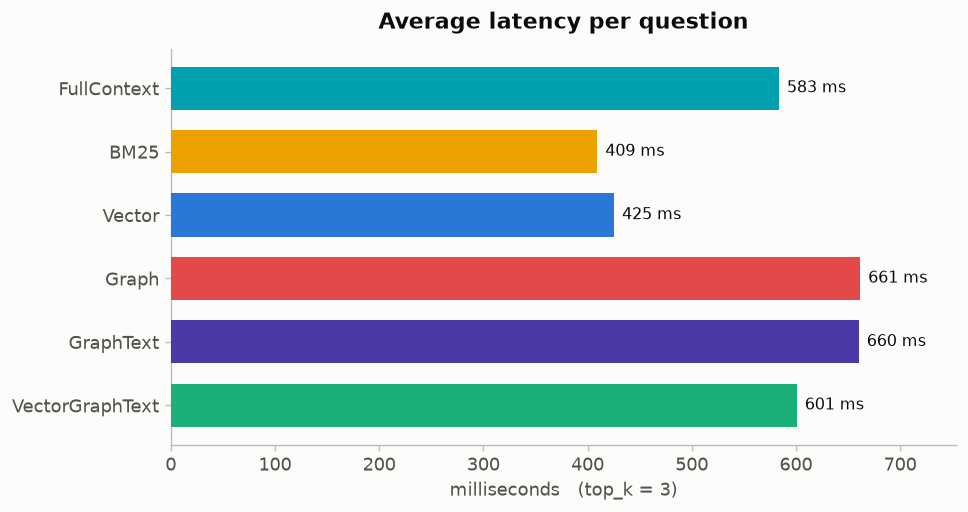

In [4]:
fig, ax = hbar_ordered(
    sdf["query_latency_ms_mean"].astype(float),
    "Average latency per question", "milliseconds", lambda v: f"{v:,.0f} ms",
)
plt.tight_layout(); plt.show()

The cheap-retrieval variants (`bm25`, `vector`) answer fastest. The graph variants and the
oracle `fullcontext` pay more — graph traversal and the larger prompts cost latency.

## 2. Average tokens per question — test-time only (no ingest)

Pure online cost from `query_tokens_total_mean`. This is what a Vector-RAG advocate would quote:
it ignores the one-time cost of building the graph.

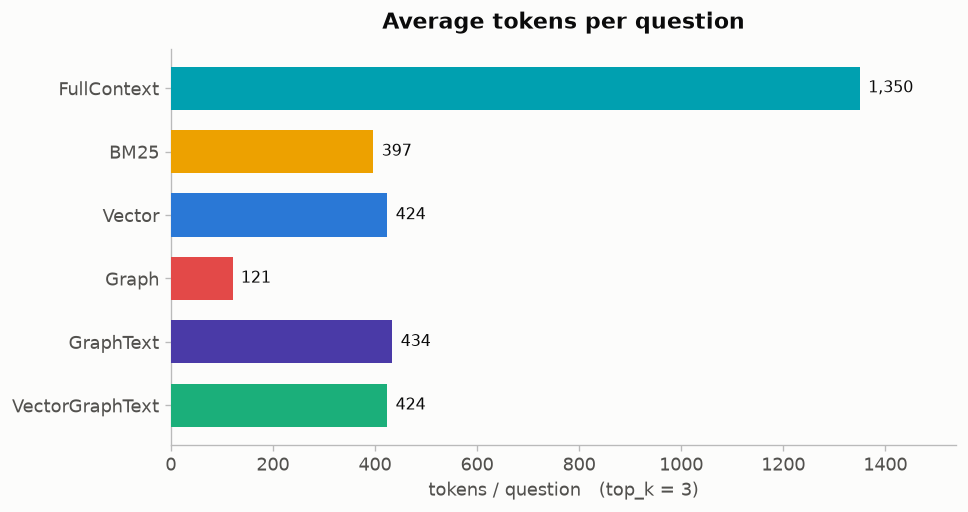

In [5]:
fig, ax = hbar_ordered(
    sdf["query_tokens_total_mean"].astype(float),
    "Average tokens per question", "tokens / question",
    lambda v: f"{v:,.0f}",
)
plt.tight_layout(); plt.show()

On raw per-query tokens the graph-only variant (`graph`) is cheapest (~120 tok)
— but it is also the least accurate (see chart 4). `fullcontext` is the most expensive (~1350 tok)
because it stuffs the whole gold context into the prompt. The realistic contenders
(`vector`, `graphtext`, `vectorgraphtext`) sit around 400–430 tok.

## 3. Average tokens per question — incl. ingest cost

The graph variants hide a large upfront cost: **6,302,709 tokens** of LLM entity/relation extraction
to build the store. Spreading that only over the variants that use the graph, across the **1000**
evaluated questions, adds **~6,303 tokens/question** (hatched). Non-graph variants
(`bm25`, `vector`, `fullcontext`) carry no ingest.

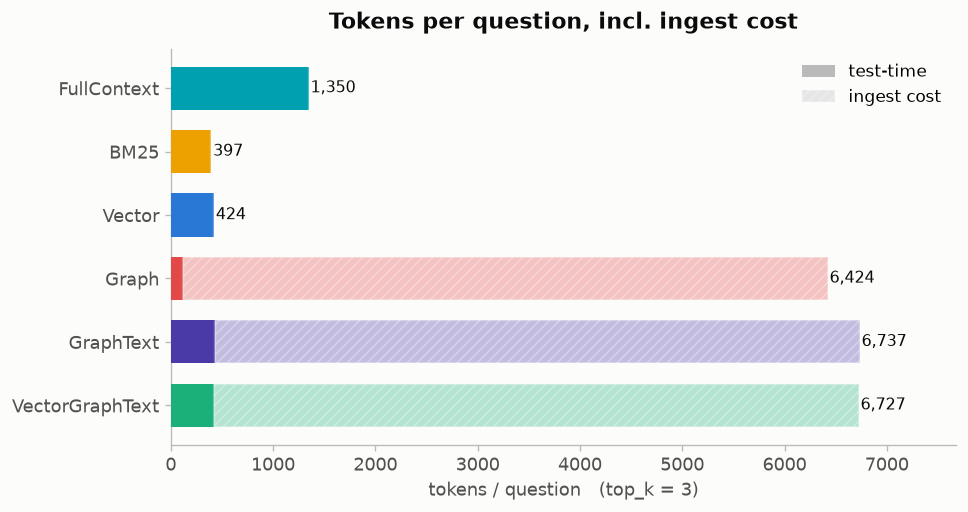

amortized ingest at n=1000: 6,303 tokens/question


In [6]:
ingest_per_q = INGEST_TOKENS / N_EVAL
ingest_extra = {v: ingest_per_q for v in GRAPH_VARIANTS}

fig, ax = hbar_ordered(
    sdf["query_tokens_total_mean"].astype(float),
    f"Tokens per question, incl. ingest cost",
    "tokens / question", lambda v: f"{v:,.0f}", extra=ingest_extra,
)
# legend distinguishing the two segments
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=MUTED, label="test-time"),
    Patch(facecolor=MUTED, alpha=0.32, hatch="////", edgecolor=SURFACE, label="ingest cost"),
], loc="upper right")
plt.tight_layout(); plt.show()

print(f"amortized ingest at n={N_EVAL}: {ingest_per_q:,.0f} tokens/question")

Amortized over only 1000 questions, the **~6,300 tok/question** of ingest completely dominates the
picture — every graph variant is suddenly the most expensive thing on the board, far past even the
`fullcontext` oracle. This is the Vector-RAG critique in one image: *the graph never pays off.*

But that conclusion depends entirely on the amortization horizon. 1000 questions is a small corpus.
The next chart asks the real question: **at what corpus size does the graph's cheaper, better search
overtake pure vector search — ingest included?**

## 4. Accuracy vs context, and the break-even point

**Baseline:** pure `vector` RAG at the `top_k` where it first *matches* `vectorgraphtext`'s accuracy.

This is two standalone charts (split so each can be copied on its own):

- **Chart 4a — accuracy vs context.** Accuracy against the *actual* context size fetched (from the
  sweep). A point to the upper-left is better: high accuracy for little context.
- **Chart 4b — break-even.** Turns the per-query token gap into a cumulative-cost race and finds
  where `vectorgraphtext` — despite paying the full ingest cost upfront — overtakes `vector`.

The next code cell computes the shared operating points and draws chart 4a; the cell after draws
chart 4b. Both are `top_k` sweeps / cumulative curves, so unlike the earlier charts they are *not*
single-`top_k` snapshots — the compared operating points are annotated inline.

vectorgraphtext @ top_k=3 :    424 tok/q, judge acc 0.516
vector          @ top_k=10:   1296 tok/q, judge acc 0.517  (first to match)
per-query saving: 872 tok  ->  break-even at N* = 7,225 questions


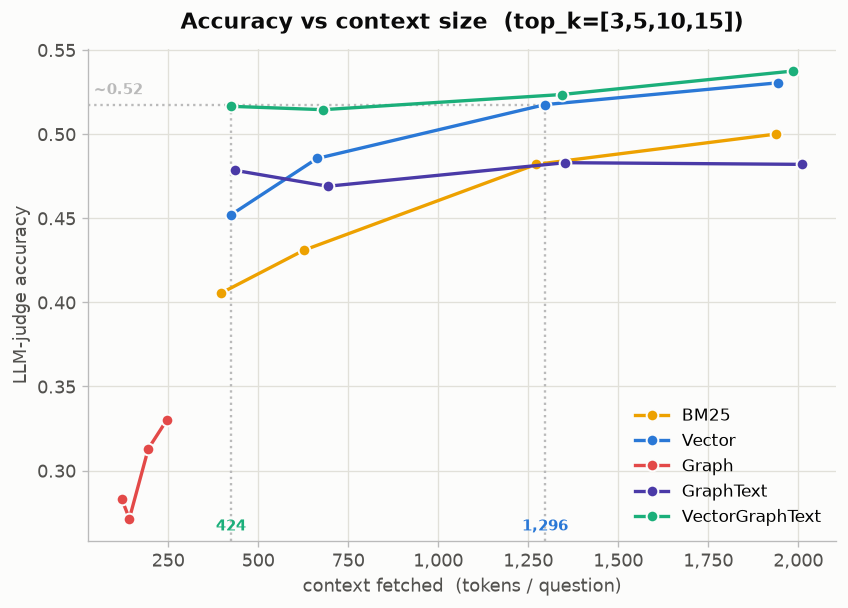

In [7]:
# --- operating points from the sweep (shared by charts 4a and 4b) ---
vg = swp[(swp.variant == "vectorgraphtext") & (swp.top_k == 3)].iloc[0]
vg_tok, vg_acc = float(vg.query_tokens_total_mean), float(vg.accuracy_judge)

# vector top_k that first matches/exceeds vectorgraphtext's accuracy = the fair comparison
vcand = swp[(swp.variant == "vector") & (swp.accuracy_judge >= vg_acc)].sort_values("top_k")
vrow = vcand.iloc[0]
v_tok, v_acc, v_topk = float(vrow.query_tokens_total_mean), float(vrow.accuracy_judge), int(vrow.top_k)

Nstar = INGEST_TOKENS / (v_tok - vg_tok)   # break-even question count
print(f"vectorgraphtext @ top_k=3 : {vg_tok:6.0f} tok/q, judge acc {vg_acc:.3f}")
print(f"vector          @ top_k={v_topk:<2}: {v_tok:6.0f} tok/q, judge acc {v_acc:.3f}  (first to match)")
print(f"per-query saving: {v_tok - vg_tok:,.0f} tok  ->  break-even at N* = {Nstar:,.0f} questions")

# ---- Chart 4a: accuracy vs context tokens (sweep) ----
fig, axA = plt.subplots(figsize=(7.2, 5.2))
for v in [x for x in VARIANT_ORDER if x in set(swp.variant)]:
    d = swp[swp.variant == v].sort_values("query_tokens_total_mean")
    axA.plot(d.query_tokens_total_mean, d.accuracy_judge, "-o", color=VARIANT_COLOR[v],
             lw=2, ms=7, label=VARIANT_LABEL[v], zorder=3,
             markeredgecolor=SURFACE, markeredgewidth=1.2)
axA.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axA.set_xlabel("context fetched  (tokens / question)")
axA.set_ylabel("LLM-judge accuracy")
axA.set_title("Accuracy vs context size  (top_k=[3,5,10,15])")
axA.legend(loc="lower right", ncol=1)

# Read the data-driven limits (this triggers their computation) and lock them, so the
# dotted guides added below can't rescale the axes. NOTE: calling autoscale(False)
# *before* the limits are computed would freeze them at the default (0, 1) and push all
# the data off-screen — leaving a blank plot.
x0, x1 = axA.get_xlim()
y0, y1 = axA.get_ylim()
axA.set_xlim(x0, x1)
axA.set_ylim(y0, y1)

# dotted guides in grey; a vertical drop per operating point (token value labelled in
# the variant's colour), plus a single shared horizontal line at the accuracy the two
# points share (~0.52), extended to the vector point.
dx, dy = (x1 - x0) * 0.008, (y1 - y0) * 0.014
for xp, yp, cvar in [(vg_tok, vg_acc, "vectorgraphtext"), (v_tok, v_acc, "vector")]:
    axA.plot([xp, xp], [y0, yp], ls=":", lw=1.4, color=MUTED, zorder=2)   # down to x-axis
    axA.text(xp, y0 + dy, f"{xp:,.0f}", ha="center", va="bottom",
             fontsize=9, color=VARIANT_COLOR[cvar], fontweight="bold", zorder=4)
y_line = v_acc   # 0.517 — single horizontal line for the matched accuracy
axA.plot([x0, max(vg_tok, v_tok)], [y_line, y_line], ls=":", lw=1.4, color=MUTED, zorder=2)
axA.text(x0 + dx, y_line + dy, f"~{y_line:.2f}", ha="left", va="bottom",
         fontsize=9, color=MUTED, fontweight="bold", zorder=4)
plt.tight_layout(); plt.show()

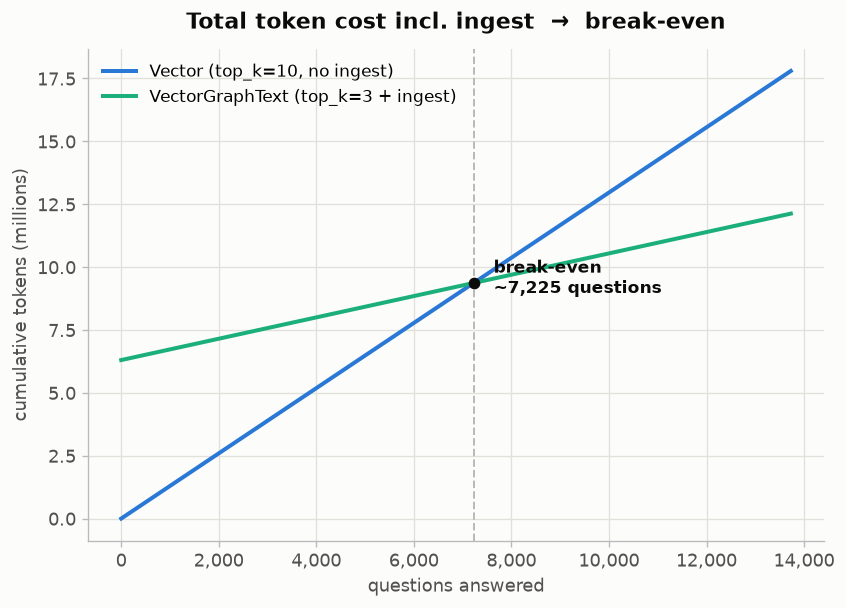

In [8]:
# ---- Chart 4b: cumulative tokens incl. ingest -> break-even ----
# (reuses v_tok, vg_tok, v_topk, Nstar from the cell above)
N = np.linspace(0, Nstar * 1.9, 400)
vec_cum = N * v_tok / 1e6
vg_cum  = (INGEST_TOKENS + N * vg_tok) / 1e6

fig, axB = plt.subplots(figsize=(7.2, 5.2))
axB.plot(N, vec_cum, color=VARIANT_COLOR["vector"], lw=2.4,
         label=f"Vector (top_k={v_topk}, no ingest)", zorder=3)
axB.plot(N, vg_cum,  color=VARIANT_COLOR["vectorgraphtext"], lw=2.4,
         label="VectorGraphText (top_k=3 + ingest)", zorder=3)
axB.axvline(Nstar, color=MUTED, ls="--", lw=1.2, zorder=2)
axB.scatter([Nstar], [(INGEST_TOKENS + Nstar * vg_tok) / 1e6], color=INK, s=36, zorder=4)
axB.annotate(f"break-even\n~{Nstar:,.0f} questions", (Nstar, (INGEST_TOKENS + Nstar * vg_tok) / 1e6),
             xytext=(12, -6), textcoords="offset points", fontsize=10, color=INK, fontweight="bold")
axB.set_xlabel("questions answered")
axB.set_ylabel("cumulative tokens (millions)")
axB.set_title("Total token cost incl. ingest  →  break-even")
axB.legend(loc="upper left")
axB.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout(); plt.show()

**Reading it.**

- **Chart 4a** — `vectorgraphtext` sits top-left: it hits its accuracy with only ~420 tokens of
  context (top_k=3). Pure `vector` has to climb its curve to **top_k=10 (~1,300 tokens)** to match
  that same accuracy — it *buys* accuracy with raw context. The graph-augmented text search finds
  the relevant chunks with roughly a third of the tokens.

- **Chart 4b** — that per-query saving (~870 tokens/question) is what repays the graph's upfront
  ingest. Below **N\* ≈ 7,200 questions** the ingest cost hasn't been earned back and pure `vector`
  is cheaper overall; beyond it, `vectorgraphtext` is the cheaper *and* more accurate system despite
  paying for the graph. On a 1,000-question benchmark (chart 3) the graph looks wasteful — but that's
  simply below break-even. At corpus/query volumes past N\*, the ingest amortizes and the better
  search wins.

## Summary

- `fullcontext` (oracle) is the accuracy ceiling — no retrieval variant beats it, as expected.
- On **test-time tokens alone**, cheap-retrieval variants look best, but the useful accuracy comes
  from `vector`, `graphtext`, and `vectorgraphtext`.
- **Ingest changes the accounting**: over a small benchmark the graph's upfront extraction cost
  dominates and makes graph variants look expensive.
- But `vectorgraphtext` reaches a given accuracy with **far less context per query** than `vector`
  (top_k=3 vs top_k=10). That per-query saving amortizes the ingest cost after the break-even
  question count (~7,200 questions here) — beyond which the graph-augmented search is both cheaper
  and more accurate.